In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from scipy import sparse
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity, rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Gene Exp

In [2]:
gene_exp = pd.read_table(
    "/Users/inouey2/Downloads/CTRPv2.1_2016_pub_NatChemBiol_12_109/v21.data.gex_avg_log2.txt"
)
gene_exp = gene_exp.pivot_table(
    columns="idx_gene_feature", index="master_ccl_id", values="mrna_expression_avg_log2"
)
gene_exp.index = list(gene_exp.index)
gene_exp.columns = list(gene_exp.columns)
cell_info = dict(
    pd.read_table(
        "/Users/inouey2/Downloads/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_cell_line.txt",
        usecols=["master_ccl_id", "ccl_name"],
    ).values
)
gene_exp.index = [cell_info[i] for i in gene_exp.index]
gene_info = dict(
    pd.read_table(
        "/Users/inouey2/Downloads/CTRPv2.1_2016_pub_NatChemBiol_12_109/v21.meta.gex_features.txt",
        usecols=["idx_gene_feature", "gene_primary_name"],
    ).values
)
gene_exp.columns = [gene_info[i] for i in gene_exp.columns]
gene_exp = gene_exp.loc[sorted(gene_exp.index), sorted(gene_exp.columns)]
gene_exp["FAM213A"] = gene_exp.loc[:, gene_exp.columns == "FAM213A"].mean(axis=1)
gene_exp["TTL"] = gene_exp.loc[:, gene_exp.columns == "TTL"].mean(axis=1)
gene_exp = gene_exp.loc[:, ~gene_exp.columns.duplicated()]
gene_exp

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAAS,AACS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
22RV1,4.980354,4.434383,7.531097,4.732491,5.487521,3.374869,3.704898,3.965432,9.142425,10.232410,...,11.003000,12.73171,5.165605,5.208990,6.540532,5.068394,8.633388,6.418384,5.888517,9.768396
2313287,4.460359,4.496125,6.034458,3.804899,4.381788,3.440269,4.359996,3.990351,8.057531,8.807101,...,10.320980,12.02617,5.702913,5.783667,6.584952,4.786077,8.325348,7.704688,5.930851,9.789415
253J,4.783156,4.156233,3.698593,4.503684,4.358112,3.552498,4.114879,4.148009,7.679034,8.416268,...,9.750890,11.41642,7.023167,5.487806,6.192945,5.273099,8.515119,8.337229,6.021771,9.479291
253JBV,4.875861,4.115867,3.576494,4.604683,4.278722,3.665464,4.030298,4.152585,7.670979,9.025579,...,10.655320,12.11153,7.121706,5.771556,6.791365,6.394393,8.451622,8.269944,5.966002,9.830135
42MGBA,8.037875,4.921515,3.605577,4.022221,3.414838,3.891536,3.714476,3.784946,8.158512,8.457420,...,10.826450,11.93199,4.684400,4.781540,5.905088,5.058623,9.064679,8.688740,5.886643,10.877220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YD8,4.679927,4.314160,3.530718,4.375905,6.149712,3.440113,4.316323,4.200849,7.714148,9.087157,...,9.370628,10.68755,5.219603,5.070393,6.282758,4.793932,9.651566,9.602900,6.594574,9.341833
YH13,7.242135,4.588566,3.684264,4.588954,3.568877,3.696379,3.942271,3.696395,8.264009,8.575915,...,10.164140,10.50267,5.038585,4.787357,6.240342,4.713769,9.060052,10.649730,5.769529,10.007170
YKG1,5.962800,4.303141,3.494644,3.880388,3.631777,3.399162,3.803461,3.986703,7.672069,8.370639,...,10.430150,11.80903,5.147716,5.257973,6.291132,5.235233,9.211799,8.652289,6.094366,10.037280
ZR751,7.731496,4.531014,3.649618,3.767514,5.773852,3.775446,4.217749,4.388632,7.250468,9.366894,...,10.398470,12.62128,5.008054,5.069002,6.836028,7.285720,8.469786,6.434814,5.656306,9.373826


# Drug Response

In [3]:
drug_response = (
    pd.read_table(
        "/Users/inouey2/Downloads/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.data.curves_post_qc.txt",
        usecols=[
            "experiment_id",
            "master_cpd_id",
            "area_under_curve",
            "apparent_ec50_umol",
        ],
    )
    .merge(
        pd.read_table(
            "/Users/inouey2/Downloads/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_experiment.txt",
            usecols=["experiment_id", "master_ccl_id"],
        )
    )
    .merge(
        pd.read_table(
            "/Users/inouey2/Downloads/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_cell_line.txt",
            usecols=["master_ccl_id", "ccl_name"],
        )
    )
    .merge(
        pd.read_table(
            "/Users/inouey2/Downloads/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_compound.txt",
            usecols=["master_cpd_id", "cpd_name"],
        )
    )
    .drop(["experiment_id", "master_ccl_id", "master_cpd_id"], axis=1)
)
drug_response

,apparent_ec50_umol,area_under_curve,ccl_name,cpd_name
0,8.9980,14.7820,CAS1,CIL55
1,20.0800,13.3270,CAS1,BRD4132
2,0.3477,16.0820,CAS1,BRD6340
3,0.3812,13.7430,CAS1,BRD9876
4,21.0000,13.3900,CAS1,betulinic acid
...,...,...,...,...
462779,0.4528,8.1182,YAMATO,avicin D
462780,1.0050,12.2020,YAMATO,BRD9876:MK-1775 (4:1 mol/mol)
462781,1.0670,9.4511,YAMATO,BRD-K30748066
462782,0.0000,13.5620,YAMATO,linsitinib


In [4]:
coexist = sorted(set(gene_exp.index) & set(drug_response.ccl_name))
drug_response = drug_response[drug_response["ccl_name"].isin(coexist)]
gene_exp = gene_exp[gene_exp.index.isin(coexist)]

<Axes: >

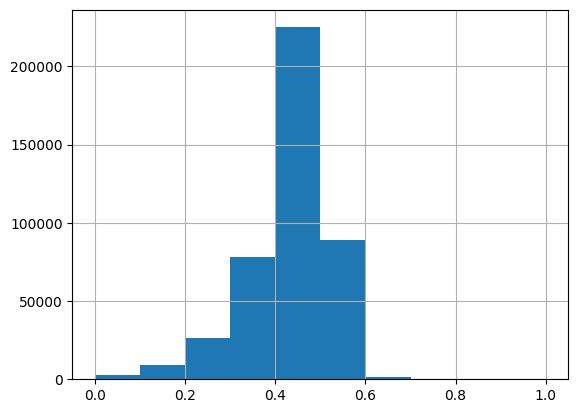

In [5]:
df = drug_response.drop("apparent_ec50_umol", axis=1)
scaler = MinMaxScaler()
df = df.rename(columns={"ccl_name": "CELL_LINE_NAME", "cpd_name": "DRUG_NAME"})
df["Z_SCORE"] = scaler.fit_transform(df[["area_under_curve"]])
df["Z_SCORE"].hist()

In [6]:
print("Min:", np.min(df["Z_SCORE"].values))
print("Max:", np.max(df["Z_SCORE"].values))
print("Mean:", np.mean(df["Z_SCORE"].values))
print("Median:", np.median(df["Z_SCORE"].values))

Min: 0.0
Max: 1.0
Mean: 0.43289124191234857
Median: 0.45657408071473204


In [7]:
l = pd.read_csv("../Figs/nsc_cid_smiles_class_name.csv", index_col=0)[
    ["NAME", "SMILES"]
]
tmp = pd.read_table(
    "/Users/inouey2/Downloads/CTRPv2.0_2015_ctd2_ExpandedDataset/v20.meta.per_compound.txt",
    usecols=["cpd_name", "cpd_smiles"],
)
tmp.columns = ["NAME", "SMILES"]
l = pd.concat([l, tmp])

In [8]:
df = df[df["DRUG_NAME"].isin(l["NAME"])]
df = df[df["CELL_LINE_NAME"].isin(set(df.CELL_LINE_NAME) & set(gene_exp.index))]
df

,area_under_curve,CELL_LINE_NAME,DRUG_NAME,Z_SCORE
0,14.782,CAS1,CIL55,0.502474
1,13.327,CAS1,BRD4132,0.452783
2,16.082,CAS1,BRD6340,0.546872
3,13.743,CAS1,BRD9876,0.466990
4,13.390,CAS1,betulinic acid,0.454935
...,...,...,...,...
448478,14.428,PANC1005,PF-4800567 hydrochloride,0.490385
448479,10.642,PANC1005,avicin D,0.361085
448480,11.463,PANC1005,BRD9876:MK-1775 (4:1 mol/mol),0.389124
448481,11.905,PANC1005,BRD-K30748066,0.404219


# Zero shot prediction

In [9]:
unique_drugs = df["DRUG_NAME"].unique()
unique_cells = df["CELL_LINE_NAME"].unique()

# Split drugs and cell lines into training, validation, and test sets
train_drugs, test_val_drugs = train_test_split(
    unique_drugs, test_size=0.5, random_state=42
)
val_drugs, test_drugs = train_test_split(test_val_drugs, test_size=0.5, random_state=42)

train_cells, test_val_cells = train_test_split(
    unique_cells, test_size=0.55, random_state=42
)
val_cells, test_cells = train_test_split(test_val_cells, test_size=0.5, random_state=42)

# Split the dataset
train_df = df[
    (df["DRUG_NAME"].isin(train_drugs)) & (df["CELL_LINE_NAME"].isin(train_cells))
]
val_df = df[(df["DRUG_NAME"].isin(val_drugs)) & (df["CELL_LINE_NAME"].isin(val_cells))]
test_df = df[
    (df["DRUG_NAME"].isin(test_drugs)) & (df["CELL_LINE_NAME"].isin(test_cells))
]

threshold = 0.5


# Function to balance label distribution
def balance_labels(df):
    positive = df[df["Z_SCORE"] > threshold]
    negative = df[df["Z_SCORE"] <= threshold]
    min_count = min(len(positive), len(negative))
    balanced_positive = positive.sample(min_count, random_state=42)
    balanced_negative = negative.sample(min_count, random_state=42)
    return pd.concat([balanced_positive, balanced_negative])


# Balance label distribution across all sets
train_df = balance_labels(train_df)
val_df = balance_labels(val_df)
test_df = balance_labels(test_df)

# Separate features and labels
X_train = train_df[["DRUG_NAME", "CELL_LINE_NAME"]]
y_train = np.array(train_df["Z_SCORE"] > threshold, dtype=float)

X_val = val_df[["DRUG_NAME", "CELL_LINE_NAME"]]
y_val = np.array(val_df["Z_SCORE"] > threshold, dtype=float)

X_test = test_df[["DRUG_NAME", "CELL_LINE_NAME"]]
y_test = np.array(test_df["Z_SCORE"] > threshold, dtype=float)

# Calculate total samples
total_samples = len(X_train) + len(X_val) + len(X_test)


# Function to calculate and format label ratios
def get_label_ratio(y):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    ratio_str = ", ".join(
        [f"Label {label}: {count/total:.2%}" for label, count in zip(unique, counts)]
    )
    return ratio_str


# Display results with percentages and label ratios
print("Train:")
print(X_train.shape, y_train.shape)
print(f"Percentage: {len(X_train)/total_samples:.2%}")
print(f"Label Ratio: {get_label_ratio(y_train)}")

print("\nValidation:")
print(X_val.shape, y_val.shape)
print(f"Percentage: {len(X_val)/total_samples:.2%}")
print(f"Label Ratio: {get_label_ratio(y_val)}")

print("\nTest:")
print(X_test.shape, y_test.shape)
print(f"Percentage: {len(X_test)/total_samples:.2%}")
print(f"Label Ratio: {get_label_ratio(y_test)}")

print(f"\nTotal samples: {total_samples}")
print(
    f"Ratio (Train:Validation:Test): {len(X_train):.0f}:{len(X_val):.0f}:{len(X_test):.0f}"
)
print(
    f"Overall Label Ratio: {get_label_ratio(np.concatenate([y_train, y_val, y_test]))}"
)

X_train.to_csv("../CTRP_data/train.csv", index=False)
X_test.to_csv("../CTRP_data/test.csv", index=False)
X_val.to_csv("../CTRP_data/val.csv", index=False)

np.save("../CTRP_data/train_labels.npy", y_train)
np.save("../CTRP_data/test_labels.npy", y_test)
np.save("../CTRP_data/val_labels.npy", y_val)

Train:
(44772, 2) (44772,)
Percentage: 66.51%
Label Ratio: Label 0.0: 50.00%, Label 1.0: 50.00%

Validation:
(11122, 2) (11122,)
Percentage: 16.52%
Label Ratio: Label 0.0: 50.00%, Label 1.0: 50.00%

Test:
(11420, 2) (11420,)
Percentage: 16.97%
Label Ratio: Label 0.0: 50.00%, Label 1.0: 50.00%

Total samples: 67314
Ratio (Train:Validation:Test): 44772:11122:11420
Overall Label Ratio: Label 0.0: 50.00%, Label 1.0: 50.00%


In [10]:
drug_response = df.pivot_table(
    columns="CELL_LINE_NAME", index="DRUG_NAME", values="Z_SCORE"
)
drug_response.index = list(drug_response.index)
drug_response.columns = list(drug_response.columns)
drug_response = drug_response.fillna(0)
drug_response

,22RV1,2313287,253J,253JBV,42MGBA,5637,639V,647V,697,769P,...,WSUDLCL2,YAPC,YD10B,YD15,YD38,YD8,YH13,YKG1,ZR751,ZR7530
16-beta-bromoandrosterone,0.495063,0.430277,0.504421,0.495781,0.507085,0.480549,0.525151,0.495746,0.000000,0.484374,...,0.547077,0.527815,0.553805,0.549980,0.509919,0.491751,0.512105,0.000000,0.530308,0.467708
"1S,3R-RSL-3",0.315243,0.347049,0.257028,0.509919,0.209976,0.262789,0.451895,0.273000,0.088942,0.257164,...,0.054500,0.445304,0.382430,0.397491,0.326978,0.192740,0.236823,0.363032,0.422149,0.209392
3-Cl-AHPC,0.348005,0.353435,0.375941,0.352103,0.302279,0.317818,0.340936,0.317173,0.233678,0.325215,...,0.359002,0.414533,0.337418,0.324956,0.403502,0.436151,0.402853,0.473513,0.485091,0.399574
968,0.488609,0.513676,0.000000,0.453910,0.000000,0.477304,0.525220,0.000000,0.000000,0.507017,...,0.525663,0.000000,0.552029,0.531025,0.523000,0.000000,0.000000,0.000000,0.000000,0.000000
A-804598,0.000000,0.000000,0.000000,0.000000,0.480788,0.000000,0.000000,0.520575,0.000000,0.000000,...,0.000000,0.509919,0.000000,0.000000,0.000000,0.494483,0.498923,0.000000,0.509919,0.478295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vorapaxar,0.452544,0.490726,0.470030,0.489428,0.452066,0.423378,0.551209,0.508724,0.000000,0.493390,...,0.452339,0.504762,0.409410,0.470918,0.502952,0.395749,0.493834,0.000000,0.478192,0.498581
vorinostat,0.353435,0.395101,0.371058,0.424540,0.418358,0.367437,0.471157,0.396774,0.341824,0.415455,...,0.319864,0.456233,0.000000,0.415284,0.168198,0.420475,0.444143,0.436220,0.452749,0.419553
vorinostat:carboplatin (1:1 mol/mol),0.428160,0.414294,0.392129,0.509919,0.472284,0.442538,0.390353,0.461731,0.380484,0.479490,...,0.365832,0.500050,0.451315,0.461799,0.479695,0.469381,0.504523,0.476143,0.484647,0.441547
vorinostat:navitoclax (4:1 mol/mol),0.424574,0.395886,0.359651,0.345205,0.437176,0.366720,0.472796,0.414431,0.276880,0.420407,...,0.364842,0.509578,0.576516,0.544857,0.525561,0.446909,0.429970,0.444211,0.435093,0.441479


In [11]:
drug_response = drug_response.fillna(0)
drug_response

,22RV1,2313287,253J,253JBV,42MGBA,5637,639V,647V,697,769P,...,WSUDLCL2,YAPC,YD10B,YD15,YD38,YD8,YH13,YKG1,ZR751,ZR7530
16-beta-bromoandrosterone,0.495063,0.430277,0.504421,0.495781,0.507085,0.480549,0.525151,0.495746,0.000000,0.484374,...,0.547077,0.527815,0.553805,0.549980,0.509919,0.491751,0.512105,0.000000,0.530308,0.467708
"1S,3R-RSL-3",0.315243,0.347049,0.257028,0.509919,0.209976,0.262789,0.451895,0.273000,0.088942,0.257164,...,0.054500,0.445304,0.382430,0.397491,0.326978,0.192740,0.236823,0.363032,0.422149,0.209392
3-Cl-AHPC,0.348005,0.353435,0.375941,0.352103,0.302279,0.317818,0.340936,0.317173,0.233678,0.325215,...,0.359002,0.414533,0.337418,0.324956,0.403502,0.436151,0.402853,0.473513,0.485091,0.399574
968,0.488609,0.513676,0.000000,0.453910,0.000000,0.477304,0.525220,0.000000,0.000000,0.507017,...,0.525663,0.000000,0.552029,0.531025,0.523000,0.000000,0.000000,0.000000,0.000000,0.000000
A-804598,0.000000,0.000000,0.000000,0.000000,0.480788,0.000000,0.000000,0.520575,0.000000,0.000000,...,0.000000,0.509919,0.000000,0.000000,0.000000,0.494483,0.498923,0.000000,0.509919,0.478295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vorapaxar,0.452544,0.490726,0.470030,0.489428,0.452066,0.423378,0.551209,0.508724,0.000000,0.493390,...,0.452339,0.504762,0.409410,0.470918,0.502952,0.395749,0.493834,0.000000,0.478192,0.498581
vorinostat,0.353435,0.395101,0.371058,0.424540,0.418358,0.367437,0.471157,0.396774,0.341824,0.415455,...,0.319864,0.456233,0.000000,0.415284,0.168198,0.420475,0.444143,0.436220,0.452749,0.419553
vorinostat:carboplatin (1:1 mol/mol),0.428160,0.414294,0.392129,0.509919,0.472284,0.442538,0.390353,0.461731,0.380484,0.479490,...,0.365832,0.500050,0.451315,0.461799,0.479695,0.469381,0.504523,0.476143,0.484647,0.441547
vorinostat:navitoclax (4:1 mol/mol),0.424574,0.395886,0.359651,0.345205,0.437176,0.366720,0.472796,0.414431,0.276880,0.420407,...,0.364842,0.509578,0.576516,0.544857,0.525561,0.446909,0.429970,0.444211,0.435093,0.441479


# Masking

In [12]:
# Validation Mask
for _, row in X_val.iterrows():
    drug_response.loc[row["DRUG_NAME"], row["CELL_LINE_NAME"]] = 0

# Test Mask
for _, row in X_test.iterrows():
    drug_response.loc[row["DRUG_NAME"], row["CELL_LINE_NAME"]] = 0

# DTI

In [13]:
dti = pd.read_csv("../data/full_table.csv")
dti = dti.dropna(subset="Drug Name").reset_index(drop=True)
dti.head()

,Drug Name,DrugBank ID,PubChem CID,PubChem SID,SMILES,Gene,NSC
0,Lepirudin,DB00001,NaN,46507011.0,NaN,F2,NaN
1,Cetuximab,DB00002,NaN,46507042.0,NaN,EGFR,NaN
2,Cetuximab,DB00002,NaN,46507042.0,NaN,FCGR3B,NaN
3,Cetuximab,DB00002,NaN,46507042.0,NaN,C1QA,NaN
4,Cetuximab,DB00002,NaN,46507042.0,NaN,C1QB,NaN


In [14]:
dti = dti[dti["Drug Name"].isin(drug_response.index)]
dti.head()

,Drug Name,DrugBank ID,PubChem CID,PubChem SID,SMILES,Gene,NSC
11264,XL765,DB05241,NaN,347910044.0,NaN,PIK3CA,NaN
11265,XL765,DB05241,NaN,347910044.0,NaN,PIK3CG,NaN
11266,XL765,DB05241,NaN,347910044.0,NaN,PIK3CD,NaN
11267,XL765,DB05241,NaN,347910044.0,NaN,PIK3CB,NaN
11268,XL765,DB05241,NaN,347910044.0,NaN,MTOR,NaN


In [15]:
print("unique drugs:", len(set(dti["Drug Name"])))
print("unique genes:", len(set(dti.Gene)))

unique drugs: 10
unique genes: 17


In [16]:
len(set(drug_response.index) & set(dti["Drug Name"]))

10

In [17]:
len(set(gene_exp.columns) & set(dti.Gene))

17

## All drugs are in drug response.

In [18]:
dti = dti[dti.Gene.isin(set(gene_exp.columns) & set(dti.Gene))]
dti

,Drug Name,DrugBank ID,PubChem CID,PubChem SID,SMILES,Gene,NSC
11264,XL765,DB05241,NaN,347910044.0,NaN,PIK3CA,NaN
11265,XL765,DB05241,NaN,347910044.0,NaN,PIK3CG,NaN
11266,XL765,DB05241,NaN,347910044.0,NaN,PIK3CD,NaN
11267,XL765,DB05241,NaN,347910044.0,NaN,PIK3CB,NaN
11268,XL765,DB05241,NaN,347910044.0,NaN,MTOR,NaN
11414,PX-12,DB05448,219104.0,175427007.0,CCC(C)SSC1=NC=CN1,TXNRD1,NaN
11628,OSI-930,DB05913,9868037.0,347827749.0,FC(F)(F)OC1=CC=C(NC(=O)C2=C(NCC3=CC=NC4=CC=CC=...,KIT,NaN
11629,OSI-930,DB05913,9868037.0,347827749.0,FC(F)(F)OC1=CC=C(NC(=O)C2=C(NCC3=CC=NC4=CC=CC=...,FLT1,NaN
11662,SNS-032,DB05969,NaN,NaN,CC(C)(C)C1=CN=C(CSC2=CN=C(NC(=O)C3CCNCC3)S2)O1,CDK7,767048.0
11663,SNS-032,DB05969,NaN,NaN,CC(C)(C)C1=CN=C(CSC2=CN=C(NC(=O)C3CCNCC3)S2)O1,CDK7,799362.0


In [19]:
dti.shape

(30, 7)

# Selected highly variable genes

In [20]:
variance = gene_exp.std()
variance = variance.sort_values(ascending=False)
variance = pd.DataFrame(variance > np.percentile(variance, 90))
variance = list(variance[variance[0] == True].index)
len(variance)

1854

In [21]:
print("DTI unique genes: ", len(set(dti["Gene"])))
print("Top 90% variable genes: ", len(variance))
print("Total: ", len(set(variance) | (set(dti["Gene"]))))

DTI unique genes:  17
Top 90% variable genes:  1854
Total:  1869


# Preprocessed data dims

In [22]:
genes = sorted(set(variance) | set(dti["Gene"]))
gene_exp = gene_exp[genes]
gene_exp.shape

(823, 1869)

# Normalize

In [23]:
gene_norm_cell = pd.DataFrame(
    StandardScaler().fit_transform(gene_exp),
    index=gene_exp.index,
    columns=gene_exp.columns,
)
gene_norm_cell

,A2M,AADAC,ABAT,ABCA1,ABCB1,ABCC2,ABCC3,ABCG2,ABI3BP,ABLIM1,...,ZNF542,ZNF608,ZNF667,ZNF711,ZNF788,ZNF804A,ZNF83,ZNF880,ZNF883,ZSCAN18
22RV1,0.158676,-0.606300,-0.172985,-1.240700,-0.655309,0.211952,-1.143489,-0.262461,-0.497076,0.275638,...,1.059161,-0.397835,0.355782,0.707090,-0.676126,-0.487965,0.978440,-0.278639,0.346665,-0.485196
2313287,-0.401652,-0.398527,-0.733476,-1.321538,-0.524865,2.237759,1.844653,-0.765663,-0.559427,2.270765,...,-1.074513,-1.337411,-0.637361,-0.827850,-0.893924,-0.784522,0.015553,-0.951011,-0.786665,-1.391447
253J,0.020461,-0.520369,-0.056395,0.777308,1.936012,-0.318172,1.239611,-0.772473,0.156429,0.826112,...,-0.911917,2.263439,-0.659820,-1.082631,-0.749390,-0.689696,0.446584,-0.630142,1.670976,0.665483
253JBV,0.081471,-0.598563,-0.583280,1.094366,-0.071753,-0.343806,1.241095,-0.507873,-0.549575,0.665687,...,-0.809401,1.809142,-0.676690,-0.849874,-0.698338,-0.576481,0.023367,-0.638559,1.178043,0.282251
42MGBA,-0.270375,-0.590035,1.143606,-0.591644,-0.655444,-0.406785,-0.702077,-0.129702,1.403195,-1.572495,...,1.181400,0.791604,0.583912,0.760792,1.506088,0.781710,0.273286,0.271732,1.766796,0.995481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YD8,-0.056726,-0.382561,1.371241,1.635160,-0.567068,-0.028813,1.564459,1.661070,0.457705,0.485480,...,-0.958809,1.219712,-0.660630,-1.097691,-0.544660,-0.718067,-0.734594,-0.928463,-0.920940,-1.378439
YH13,0.071970,-0.467418,-0.988106,0.401892,-0.572986,-0.578843,1.049290,-0.870617,2.256564,-0.678452,...,1.327501,0.980004,1.704673,-0.214468,0.233691,0.560118,0.661925,1.225758,1.590718,1.456543
YKG1,-0.356052,-0.484393,-0.507983,1.227946,-0.468741,-0.379800,-0.164492,1.025528,-0.509788,-0.620057,...,0.834953,0.212447,1.926357,0.325499,0.300129,1.179555,1.018109,-0.891720,2.139634,1.288327
ZR751,-0.424235,0.001393,2.349116,0.105280,-0.454173,0.764632,-0.389431,-0.369782,-0.464396,0.446096,...,-0.925244,-0.315218,-0.764392,1.043296,-0.973876,-0.584194,0.481526,-0.843894,-0.115986,-0.641911


In [24]:
gene_norm_gene = pd.DataFrame(
    StandardScaler().fit_transform(gene_exp.T),
    index=gene_exp.columns,
    columns=gene_exp.index,
).T
gene_norm_gene

,A2M,AADAC,ABAT,ABCA1,ABCB1,ABCC2,ABCC3,ABCG2,ABI3BP,ABLIM1,...,ZNF542,ZNF608,ZNF667,ZNF711,ZNF788,ZNF804A,ZNF83,ZNF880,ZNF883,ZSCAN18
22RV1,-0.679831,-1.133744,-0.394264,-0.742369,-1.125525,-0.323257,-0.755850,-0.339726,-0.805407,0.944386,...,0.641991,-0.169869,-0.458790,0.272081,-0.784558,-0.846322,1.139916,-0.600043,-0.378613,-0.352432
2313287,-1.014358,-0.947514,-0.740855,-0.790639,-0.975139,1.085614,1.281974,-0.727960,-0.826311,1.969075,...,-1.000789,-0.804941,-1.029923,-0.923908,-0.904795,-1.003343,0.347314,-1.026886,-1.154784,-1.101722
253J,-0.842106,-1.108116,-0.436249,0.798207,0.627334,-0.820990,0.799232,-0.818611,-0.401706,1.020842,...,-0.973992,1.358145,-1.130616,-1.193617,-0.897634,-1.031569,0.533006,-0.910294,0.391716,0.452890
253JBV,-0.861085,-1.225998,-0.794080,1.070657,-0.806038,-0.897409,0.809366,-0.679460,-0.966560,0.936937,...,-0.962265,1.094690,-1.210414,-1.092664,-0.923367,-1.023307,0.262049,-0.976805,0.042634,0.129094
42MGBA,-1.026150,-1.154235,0.246641,-0.301658,-1.156788,-0.889820,-0.530112,-0.367524,0.478518,-0.451862,...,0.492215,0.428842,-0.439546,0.117515,0.563628,-0.113720,0.417336,-0.342196,0.445585,0.705711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YD8,-0.997345,-1.131008,0.260261,1.339512,-1.196412,-0.725109,0.884147,0.781093,-0.304819,0.679386,...,-1.112949,0.574454,-1.235092,-1.307317,-0.873605,-1.154670,-0.306795,-1.205053,-1.434163,-1.283253
YH13,-0.925260,-1.188203,-1.086650,0.368731,-1.207512,-1.120744,0.537765,-1.002579,0.961178,-0.024011,...,0.474242,0.425867,0.069728,-0.689644,-0.377462,-0.366561,0.532814,0.146170,0.210284,0.948311
YKG1,-1.158100,-1.170858,-0.766623,1.156509,-1.106302,-0.941380,-0.207359,0.435880,-0.954017,0.097892,...,0.223322,0.035557,0.288199,-0.236423,-0.264918,0.105718,0.870605,-1.161125,0.685451,0.941444
ZR751,-1.111533,-0.760148,1.149201,0.395470,-1.000002,0.061250,-0.230551,-0.472184,-0.814909,0.971475,...,-0.966244,-0.167268,-1.191404,0.468394,-1.032631,-0.946339,0.715329,-1.035400,-0.762958,-0.537771


# Make matrices association matrices by setting 0 threshold and min max scaler.

In [25]:
def min_max_scale(data):
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = data[data > 0].fillna(0)
    return pd.DataFrame(
        scaler.fit_transform(data), index=data.index, columns=data.columns
    )

In [26]:
A_dc = min_max_scale(drug_response)
A_dc

,22RV1,2313287,253J,253JBV,42MGBA,5637,639V,647V,697,769P,...,WSUDLCL2,YAPC,YD10B,YD15,YD38,YD8,YH13,YKG1,ZR751,ZR7530
16-beta-bromoandrosterone,0.875679,0.712410,0.871746,0.669602,0.873462,0.832603,0.907465,0.897378,0.000000,0.824832,...,0.884441,0.898128,0.887866,0.873366,0.858547,0.784942,0.906096,0.000000,0.851689,0.795757
"1S,3R-RSL-3",0.557609,0.574609,0.444198,0.688698,0.361688,0.455310,0.780878,0.494173,0.145176,0.437921,...,0.088108,0.757728,0.613117,0.631214,0.550529,0.307655,0.419025,0.656009,0.677982,0.356260
3-Cl-AHPC,0.615559,0.585183,0.649706,0.475551,0.520681,0.550654,0.589139,0.574132,0.381422,0.553804,...,0.580386,0.705368,0.540952,0.516029,0.679373,0.696193,0.712791,0.855652,0.779069,0.679835
968,0.864262,0.850494,0.000000,0.613052,0.000000,0.826981,0.000000,0.000000,0.000000,0.863390,...,0.849822,0.000000,0.885019,0.843266,0.880570,0.000000,0.000000,0.000000,0.000000,0.000000
A-804598,0.000000,0.000000,0.000000,0.000000,0.828165,0.000000,0.000000,0.942322,0.000000,0.000000,...,0.000000,0.867677,0.000000,0.000000,0.000000,0.789303,0.882772,0.000000,0.818944,0.813770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vorapaxar,0.800470,0.812495,0.812311,0.661022,0.778692,0.733549,0.000000,0.000000,0.000000,0.840185,...,0.731282,0.858902,0.656371,0.747816,0.846816,0.631703,0.873768,0.000000,0.767989,0.848285
vorinostat,0.625164,0.654168,0.641266,0.573384,0.720629,0.636625,0.814162,0.718223,0.557944,0.707471,...,0.517113,0.776324,0.000000,0.659470,0.283194,0.671171,0.785847,0.788261,0.727127,0.713828
vorinostat:carboplatin (1:1 mol/mol),0.757338,0.685947,0.677682,0.688698,0.813517,0.766744,0.674533,0.835805,0.621047,0.816515,...,0.591429,0.850882,0.723553,0.733336,0.807658,0.749235,0.892682,0.860404,0.778356,0.751248
vorinostat:navitoclax (4:1 mol/mol),0.750995,0.655469,0.621552,0.466234,0.753043,0.635382,0.816995,0.750184,0.451940,0.715904,...,0.589828,0.000000,0.000000,0.865231,0.884882,0.713365,0.760770,0.802702,0.000000,0.751132


In [27]:
A_cg = min_max_scale(gene_norm_gene + gene_norm_cell)
A_cg

,A2M,AADAC,ABAT,ABCA1,ABCB1,ABCC2,ABCC3,ABCG2,ABI3BP,ABLIM1,...,ZNF542,ZNF608,ZNF667,ZNF711,ZNF788,ZNF804A,ZNF83,ZNF880,ZNF883,ZSCAN18
22RV1,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.249084,...,0.345347,0.000000,0.000000,0.228120,0.000000,0.000000,0.650080,0.00000,0.000000,0.000000
2313287,0.0,0.0,0.000000,0.000000,0.00000,0.573130,0.718677,0.000000,0.000000,0.865619,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111356,0.00000,0.000000,0.000000
253J,0.0,0.0,0.000000,0.343613,0.38597,0.000000,0.468642,0.000000,0.000000,0.377080,...,0.000000,0.667014,0.000000,0.000000,0.000000,0.000000,0.300616,0.00000,0.408266,0.295036
253JBV,0.0,0.0,0.000000,0.472182,0.00000,0.000000,0.471313,0.000000,0.000000,0.327197,...,0.000000,0.534820,0.000000,0.000000,0.000000,0.000000,0.087588,0.00000,0.241607,0.108516
42MGBA,0.0,0.0,0.255234,0.000000,0.00000,0.000000,0.000000,0.000000,0.299006,0.000000,...,0.339757,0.224778,0.036393,0.204622,0.432659,0.125105,0.211938,0.00000,0.437894,0.448789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YD8,0.0,0.0,0.299526,0.648763,0.00000,0.000000,0.562829,0.389125,0.024294,0.237823,...,0.000000,0.330445,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
YH13,0.0,0.0,0.000000,0.168070,0.00000,0.000000,0.364795,0.000000,0.511302,0.000000,...,0.365768,0.258930,0.447307,0.000000,0.000000,0.036250,0.366641,0.29021,0.356470,0.634420
YKG1,0.0,0.0,0.000000,0.520039,0.00000,0.000000,0.000000,0.232855,0.000000,0.000000,...,0.214838,0.045677,0.558266,0.020752,0.007360,0.240713,0.579608,0.00000,0.559166,0.588232
ZR751,0.0,0.0,0.642253,0.109212,0.00000,0.142427,0.000000,0.000000,0.000000,0.289416,...,0.000000,0.000000,0.000000,0.352183,0.000000,0.000000,0.367290,0.00000,0.000000,0.000000


In [28]:
A_dg = (
    pd.DataFrame(
        np.ones([len(A_dc.index), len(A_cg.columns)]),
        index=A_dc.index,
        columns=A_cg.columns,
    )
    / 2
)
for _, i in dti.iterrows():
    A_dg.loc[i["Drug Name"], i["Gene"]] = 1
A_dg

,A2M,AADAC,ABAT,ABCA1,ABCB1,ABCC2,ABCC3,ABCG2,ABI3BP,ABLIM1,...,ZNF542,ZNF608,ZNF667,ZNF711,ZNF788,ZNF804A,ZNF83,ZNF880,ZNF883,ZSCAN18
16-beta-bromoandrosterone,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
"1S,3R-RSL-3",0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
3-Cl-AHPC,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
968,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
A-804598,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vorapaxar,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
vorinostat,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
vorinostat:carboplatin (1:1 mol/mol),0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
vorinostat:navitoclax (4:1 mol/mol),0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


In [29]:
drug_response

,22RV1,2313287,253J,253JBV,42MGBA,5637,639V,647V,697,769P,...,WSUDLCL2,YAPC,YD10B,YD15,YD38,YD8,YH13,YKG1,ZR751,ZR7530
16-beta-bromoandrosterone,0.495063,0.430277,0.504421,0.495781,0.507085,0.480549,0.525151,0.495746,0.000000,0.484374,...,0.547077,0.527815,0.553805,0.549980,0.509919,0.491751,0.512105,0.000000,0.530308,0.467708
"1S,3R-RSL-3",0.315243,0.347049,0.257028,0.509919,0.209976,0.262789,0.451895,0.273000,0.088942,0.257164,...,0.054500,0.445304,0.382430,0.397491,0.326978,0.192740,0.236823,0.363032,0.422149,0.209392
3-Cl-AHPC,0.348005,0.353435,0.375941,0.352103,0.302279,0.317818,0.340936,0.317173,0.233678,0.325215,...,0.359002,0.414533,0.337418,0.324956,0.403502,0.436151,0.402853,0.473513,0.485091,0.399574
968,0.488609,0.513676,0.000000,0.453910,0.000000,0.477304,0.000000,0.000000,0.000000,0.507017,...,0.525663,0.000000,0.552029,0.531025,0.523000,0.000000,0.000000,0.000000,0.000000,0.000000
A-804598,0.000000,0.000000,0.000000,0.000000,0.480788,0.000000,0.000000,0.520575,0.000000,0.000000,...,0.000000,0.509919,0.000000,0.000000,0.000000,0.494483,0.498923,0.000000,0.509919,0.478295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vorapaxar,0.452544,0.490726,0.470030,0.489428,0.452066,0.423378,0.000000,0.000000,0.000000,0.493390,...,0.452339,0.504762,0.409410,0.470918,0.502952,0.395749,0.493834,0.000000,0.478192,0.498581
vorinostat,0.353435,0.395101,0.371058,0.424540,0.418358,0.367437,0.471157,0.396774,0.341824,0.415455,...,0.319864,0.456233,0.000000,0.415284,0.168198,0.420475,0.444143,0.436220,0.452749,0.419553
vorinostat:carboplatin (1:1 mol/mol),0.428160,0.414294,0.392129,0.509919,0.472284,0.442538,0.390353,0.461731,0.380484,0.479490,...,0.365832,0.500050,0.451315,0.461799,0.479695,0.469381,0.504523,0.476143,0.484647,0.441547
vorinostat:navitoclax (4:1 mol/mol),0.424574,0.395886,0.359651,0.345205,0.437176,0.366720,0.472796,0.414431,0.276880,0.420407,...,0.364842,0.000000,0.000000,0.544857,0.525561,0.446909,0.429970,0.444211,0.000000,0.441479


In [30]:
print(
    "Drug Density: ",
    round(len(A_dc.values.nonzero()[0]) / drug_response.size, 4) * 100,
    "%",
)
print("Cell Density: ", round(len(A_cg.values.nonzero()[0]) / A_cg.size, 4) * 100, "%")
print("Gene Density: ", round(len(A_dg.values.nonzero()[0]) / A_dg.size, 5) * 100, "%")

Drug Density:  75.29 %
Cell Density:  43.96 %
Gene Density:  100.0 %


# Similarity

In [31]:
def normalize_similarity_matrix(df, gamma=None):
    similarity_matrix = rbf_kernel(df.values, gamma=gamma)
    scaler = MinMaxScaler()
    normalized_matrix = scaler.fit_transform(similarity_matrix.reshape(-1, 1))
    normalized_df = pd.DataFrame(
        normalized_matrix.reshape(similarity_matrix.shape),
        index=df.index,
        columns=df.index,
    )

    return normalized_df

In [32]:
cell_sim = normalize_similarity_matrix(drug_response.T)
cell_sim.to_csv("../CTRP_data/cell_sim.csv")
cell_sim

,22RV1,2313287,253J,253JBV,42MGBA,5637,639V,647V,697,769P,...,WSUDLCL2,YAPC,YD10B,YD15,YD38,YD8,YH13,YKG1,ZR751,ZR7530
22RV1,1.000000,0.866857,0.863546,0.727682,0.653560,0.896704,0.829749,0.659819,0.596819,0.873886,...,0.917096,0.710950,0.769299,0.919276,0.922500,0.796731,0.705633,0.627164,0.710137,0.688314
2313287,0.866857,1.000000,0.787960,0.659254,0.640399,0.807872,0.743034,0.649402,0.624579,0.872856,...,0.857366,0.763090,0.810756,0.835720,0.841194,0.767060,0.697286,0.627801,0.754559,0.673100
253J,0.863546,0.787960,1.000000,0.716851,0.596500,0.824422,0.767016,0.597402,0.573926,0.759018,...,0.860702,0.646308,0.722532,0.859041,0.853900,0.724682,0.634068,0.557232,0.640509,0.626306
253JBV,0.727682,0.659254,0.716851,1.000000,0.578236,0.747968,0.760879,0.586834,0.533955,0.635581,...,0.722490,0.533260,0.595326,0.711915,0.699471,0.626075,0.544568,0.507174,0.550478,0.523612
42MGBA,0.653560,0.640399,0.596500,0.578236,1.000000,0.684152,0.683342,0.843053,0.711368,0.584590,...,0.650059,0.662642,0.533741,0.630560,0.625031,0.766137,0.844433,0.754011,0.652542,0.835492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YD8,0.796731,0.767060,0.724682,0.626075,0.766137,0.760701,0.737569,0.764160,0.649917,0.734083,...,0.774177,0.828568,0.650993,0.771740,0.771465,1.000000,0.841131,0.707611,0.834073,0.799979
YH13,0.705633,0.697286,0.634068,0.544568,0.844433,0.690560,0.643290,0.864939,0.737552,0.642283,...,0.705875,0.715183,0.588500,0.677775,0.680924,0.841131,1.000000,0.808388,0.729557,0.907807
YKG1,0.627164,0.627801,0.557232,0.507174,0.754011,0.630076,0.566358,0.727010,0.873566,0.581329,...,0.620111,0.632037,0.542810,0.593571,0.590013,0.707611,0.808388,1.000000,0.635451,0.800074
ZR751,0.710137,0.754559,0.640509,0.550478,0.652542,0.675197,0.611360,0.651462,0.595737,0.756370,...,0.690702,0.887621,0.678381,0.674383,0.679673,0.834073,0.729557,0.635451,1.000000,0.716430


In [33]:
print("Min:", np.min(cell_sim.values))
print("Max:", np.max(cell_sim.values))
print("Mean:", np.mean(cell_sim.values))
print("Median:", np.median(cell_sim.values))

Min: 0.0
Max: 1.0
Mean: 0.7041514107703292
Median: 0.715143606616242


In [34]:
gene_sim = normalize_similarity_matrix(gene_norm_cell.T)
gene_sim.to_csv("../nci_data/gene_sim.csv")
gene_sim

,A2M,AADAC,ABAT,ABCA1,ABCB1,ABCC2,ABCC3,ABCG2,ABI3BP,ABLIM1,...,ZNF542,ZNF608,ZNF667,ZNF711,ZNF788,ZNF804A,ZNF83,ZNF880,ZNF883,ZSCAN18
A2M,1.000000,0.095524,0.120576,0.109866,0.116799,0.176749,0.092091,0.112559,0.138844,0.082542,...,0.156323,0.147904,0.125205,0.095446,0.122449,0.109268,0.103690,0.146335,0.135101,0.100116
AADAC,0.095524,1.000000,0.084460,0.170763,0.118699,0.179899,0.265035,0.217615,0.120647,0.192831,...,0.080241,0.085391,0.078620,0.079091,0.069359,0.080913,0.082682,0.081890,0.123778,0.090706
ABAT,0.120576,0.084460,1.000000,0.079192,0.130673,0.083076,0.087689,0.100819,0.083838,0.144395,...,0.128389,0.122696,0.119563,0.164182,0.105531,0.112003,0.148068,0.133286,0.119815,0.135832
ABCA1,0.109866,0.170763,0.079192,1.000000,0.099396,0.133131,0.181001,0.156135,0.223022,0.095521,...,0.119680,0.137197,0.129330,0.064956,0.135528,0.108022,0.114242,0.109481,0.142689,0.136081
ABCB1,0.116799,0.118699,0.130673,0.099396,1.000000,0.158707,0.147071,0.106001,0.105397,0.145840,...,0.105475,0.159986,0.109595,0.148082,0.089851,0.137347,0.090604,0.097770,0.097047,0.095903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF804A,0.109268,0.080913,0.112003,0.108022,0.137347,0.081699,0.046552,0.071362,0.123141,0.058805,...,0.149890,0.115881,0.166462,0.216091,0.191132,1.000000,0.130294,0.135369,0.119543,0.127249
ZNF83,0.103690,0.082682,0.148068,0.114242,0.090604,0.080376,0.097673,0.079673,0.142437,0.092994,...,0.215259,0.169875,0.209581,0.142944,0.219545,0.130294,1.000000,0.248433,0.164235,0.277009
ZNF880,0.146335,0.081890,0.133286,0.109481,0.097770,0.090355,0.086839,0.099653,0.152691,0.076935,...,0.368089,0.158035,0.312384,0.142836,0.205610,0.135369,0.248433,1.000000,0.212496,0.340392
ZNF883,0.135101,0.123778,0.119815,0.142689,0.097047,0.101049,0.101044,0.123465,0.157094,0.088202,...,0.310774,0.115398,0.232571,0.136856,0.165946,0.119543,0.164235,0.212496,1.000000,0.241614


In [35]:
print("Min:", np.min(gene_sim.values))
print("Max:", np.max(gene_sim.values))
print("Mean:", np.mean(gene_sim.values))
print("Median:", np.median(gene_sim.values))

Min: 0.0
Max: 1.0
Mean: 0.1371586494309053
Median: 0.12163662614574663


# NSC to SMILES

In [36]:
l

,NAME,SMILES
0,p-Toluquinone,CC1=CC(=O)C=CC1=O
1,4-Amino-3-pentadecylphenol,CCCCCCCCCCCCCCCC1=C(C=CC(=C1)O)N
2,3-(Dimethylamino)propiophenone hydrochloride,CN(C)CCC(=O)C1=CC=CC=C1.Cl
3,Cycloheximide,CC1CC(C(=O)C(C1)C(CC2CC(=O)NC(=O)C2)O)C
4,Cycloheximide,CC1CC(C(=O)C(C1)C(CC2CC(=O)NC(=O)C2)O)C
...,...,...
540,avicin D,CC1O[C@@H](OCC2O[C@@H](O[C@H]3CC[C@@]4(C)C(CC[...
541,BRD9876:MK-1775 (4:1 mol/mol),CC(C)(C)c1ccc2cc(C#N)c(cc2c1)C#N.CN1CCN(CC1)c1...
542,BRD-K30748066,Cc1c(sc(=O)n1C)-c1ccnc(Nc2ccc(cc2)N2CCNCC2)n1
543,linsitinib,CC1(O)CC(C1)c2nc(c3ccc4ccc(nc4c3)c5ccccc5)c6c(...


In [37]:
convert = dict(l.values)
SMILES = [convert[i] for i in drug_response.index]
SMILES

['C[C@]12CC[C@H]3[C@@H](CC[C@H]4C[C@H](O)CC[C@]34C)[C@@H]1C[C@H](Br)C2=O',
 'COC(=O)[C@H]1Cc2c([nH]c3ccccc23)[C@@H](N1C(=O)CCl)c1ccc(cc1)C(=O)OC',
 'OC(=O)\\C=C\\c1ccc(c(Cl)c1)-c1ccc(O)c(c1)C12C[C@H]3C[C@H](C[C@H](C3)C1)C2',
 'CN(C)c1ccc(cc1Br)C1Nc2ccc3ccccc3c2C2=C1C(=O)CC(C)(C)C2',
 'C[C@H](\\N=C(\\NC#N)Nc1cccc2ncccc12)c1ccccc1',
 'CCCCC\\C=C/C\\C=C/C\\C=C/C\\C=C/CCCC(=O)C(F)(F)F',
 'CC1(C)CCC(CN2CCN(CC2)c2ccc(C(=O)NS(=O)(=O)c3ccc(NCC4CCOCC4)c(c3)[N+]([O-])=O)c(Oc3cnc4[nH]ccc4c3)c2)=C(C1)c1ccc(Cl)cc1',
 'CN(C)CC[C@H](CSc1ccccc1)Nc1ccc(cc1[N+]([O-])=O)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(Cc2ccccc2-c2ccc(Cl)cc2)CC1',
 'CCCCCCCCc1ccc(cc1)-c1ccc(cc1)C(O)=O',
 'Clc1ccc(Cl)c(c1)-c1ccc(\\C=C(/C#N)C(=O)Nc2cccc3ncccc23)o1',
 'CC1(C)CCC(C)(C)c2cc(ccc12)C(=O)Nc1ccc(cc1)C(O)=O',
 'CNC(C)C(=O)NC1CN(CCC2CCC(N2C1=O)C(=O)NC(c3ccccc3)c4ccccc4)C(=O)CC(C)C',
 'CC(C)c1cc(C(=O)N2Cc3ccc(CN4CCN(C)CC4)cc3C2)c(O)cc1O',
 'Clc1ccc(cc1)C1(CCNCC1)c1ccc(cc1)-c1cn[nH]c1',
 'COc1cc(OC2CCN(C)CC2)ccc1Nc1ncc2n(C)c(=O)n(C3CCC

In [38]:
def get_morgan_fingerprint(SMILES):
    # Initialize parser parameters
    params = Chem.SmilesParserParams()
    params.useChirality = True  # Preserve stereochemistry information
    params.removeHs = False  # Keep hydrogen atoms
    mfp = []

    for smi in SMILES:
        mol = None
        # Sanitization attempt strategies
        sanitize_attempts = [
            {"sanitize": True},  # First try with standard sanitization
            {
                "sanitize": False,
                "partial_sanitize": True,
            },  # Fallback: partial sanitization
        ]

        for attempt in sanitize_attempts:
            try:
                # Update parameters for this attempt
                current_params = Chem.SmilesParserParams()
                current_params.sanitize = attempt["sanitize"]
                current_params.useChirality = params.useChirality
                current_params.removeHs = params.removeHs

                # Molecule object creation
                mol = Chem.MolFromSmiles(smi, params=current_params)

                if mol and "partial_sanitize" in attempt:
                    # Perform partial sanitization (skip property validation)
                    Chem.SanitizeMol(mol, Chem.SANITIZE_ALL ^ Chem.SANITIZE_PROPERTIES)

                if mol:  # Successfully processed molecule
                    # Generate Morgan fingerprint
                    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
                    mfp.append(np.array(fp))
                    break  # Exit attempt loop on success

            except Exception as e:
                if attempt == sanitize_attempts[-1]:  # Final attempt failed
                    print(f"Processing failed: {smi}")
                    print(f"Error details: {str(e)}")
                continue  # Try next attempt

        if not mol:  # All attempts failed
            print(f"Complete processing failure: {smi}")
            mfp.append(np.zeros(2048))  # Insert zero-vector placeholder

    return np.array(mfp)

In [39]:
mfp = get_morgan_fingerprint(SMILES)
mfp = pd.DataFrame(mfp, index=drug_response.index)

In [40]:
drug_sim = normalize_similarity_matrix(mfp)
drug_sim.to_csv("../CTRP_data/drug_sim.csv")
drug_sim

,16-beta-bromoandrosterone,"1S,3R-RSL-3",3-Cl-AHPC,968,A-804598,AA-COCF3,ABT-199,ABT-737,AC55649,AGK-2,...,tubastatin A,valdecoxib,vandetanib,veliparib,vincristine,vorapaxar,vorinostat,vorinostat:carboplatin (1:1 mol/mol),vorinostat:navitoclax (4:1 mol/mol),zebularine
16-beta-bromoandrosterone,1.000000,0.718910,0.766108,0.739098,0.728997,0.793223,0.582529,0.618852,0.793223,0.685394,...,0.739098,0.766108,0.712194,0.783042,0.595715,0.695432,0.793223,0.766108,0.543127,0.789828
"1S,3R-RSL-3",0.718910,1.000000,0.712194,0.725633,0.728997,0.759345,0.562799,0.632108,0.786434,0.698781,...,0.779652,0.745841,0.698781,0.755967,0.662030,0.662030,0.786434,0.739098,0.543127,0.755967
3-Cl-AHPC,0.766108,0.712194,1.000000,0.705484,0.722271,0.772877,0.595715,0.638746,0.800018,0.718910,...,0.732362,0.779652,0.685394,0.755967,0.608926,0.688738,0.800018,0.766108,0.569370,0.755967
968,0.739098,0.725633,0.705484,1.000000,0.708838,0.732362,0.582529,0.605621,0.752590,0.672034,...,0.732362,0.752590,0.685394,0.749214,0.582529,0.642068,0.766108,0.732362,0.543127,0.742469
A-804598,0.728997,0.728997,0.722271,0.708838,1.000000,0.762726,0.566084,0.642068,0.789828,0.830680,...,0.749214,0.783042,0.722271,0.759345,0.585823,0.678711,0.810224,0.755967,0.552956,0.779652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vorapaxar,0.695432,0.662030,0.688738,0.642068,0.678711,0.722271,0.552956,0.556236,0.728997,0.655370,...,0.675371,0.722271,0.662030,0.685394,0.539854,1.000000,0.722271,0.688738,0.500701,0.732362
vorinostat,0.793223,0.786434,0.800018,0.766108,0.810224,0.854621,0.602317,0.692084,0.875208,0.766108,...,0.827267,0.834095,0.752590,0.810224,0.642068,0.722271,1.000000,0.944266,0.708838,0.830680
vorinostat:carboplatin (1:1 mol/mol),0.766108,0.739098,0.766108,0.732362,0.755967,0.800018,0.582529,0.652042,0.820445,0.718910,...,0.779652,0.786434,0.705484,0.783042,0.615542,0.688738,0.944266,1.000000,0.688738,0.789828
vorinostat:navitoclax (4:1 mol/mol),0.543127,0.543127,0.569370,0.543127,0.552956,0.595715,0.652042,0.749214,0.622163,0.530044,...,0.622163,0.602317,0.530044,0.572657,0.435953,0.500701,0.708838,0.688738,1.000000,0.572657


In [41]:
print("Min:", np.min(drug_sim.values))
print("Max:", np.max(drug_sim.values))
print("Mean:", np.mean(drug_sim.values))
print("Median:", np.median(drug_sim.values))

Min: 0.0
Max: 1.0
Mean: 0.6757697915107326
Median: 0.6954317689252134


# Unified Graph

In [42]:
indexes = list(A_dc.index) + list(A_cg.index) + list(A_dg.columns)
n_all = len(indexes)
base = pd.DataFrame(np.zeros([n_all, n_all]), index=indexes, columns=indexes)
base

,16-beta-bromoandrosterone,"1S,3R-RSL-3",3-Cl-AHPC,968,A-804598,AA-COCF3,ABT-199,ABT-737,AC55649,AGK-2,...,ZNF542,ZNF608,ZNF667,ZNF711,ZNF788,ZNF804A,ZNF83,ZNF880,ZNF883,ZSCAN18
16-beta-bromoandrosterone,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"1S,3R-RSL-3",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3-Cl-AHPC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A-804598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF804A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ZNF83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ZNF880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ZNF883,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
base.loc[A_cg.index, A_cg.columns] = A_cg
base.loc[A_cg.columns, A_cg.index] = A_cg.T
base.loc[A_dc.index, A_dc.columns] = A_dc
base.loc[A_dc.columns, A_dc.index] = A_dc.T
base.loc[A_dg.index, A_dg.columns] = A_dg
base.loc[A_dg.columns, A_dg.index] = A_dg.T

In [44]:
edge_index = np.array(base.values.nonzero())
edge_attr = np.array(base.values[base.values.nonzero()])

np.save(
    "../CTRP_data/idxs.npy",
    pd.DataFrame([list(range(len(base.index))), base.index]).values,
)

np.save(
    "../CTRP_data/edge_idxs.npy",
    edge_index,
)

np.save(
    "../CTRP_data/edge_attr.npy",
    edge_attr,
)